# 비지도 학습 군집분석: 정답지가 없는 분석

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib

In [60]:
data = pd.read_csv("./data/shopping-data.csv")
data

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [61]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [62]:
data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [63]:
data.boxplot()

<Axes: >

# 군집분석(계층적 군집, 비계층적 군집)
: 비슷한 특징을 가진 데이터끼리 자동으로 묶는 분석 방법
* 계층적 군집
  * 비지도학습
  * 데이터가 적을 때 사용
  * 거리 계산 지표: 가까운 거리에 있는 애들끼리 묶어주는 것 \
    예) 유클리드, 맨하탄, 코사인 유사도
* 계층적 군집 5가지
  * 단일연결법(single linkage), 최단연결법: 군집과 군집 사이에서 **가장 가까운 데이터**를 기준으로 묶음
  * 완전연결법(complite linkage), 최장연결법: 군집과 군집 사이에서 **가장 먼 데이터**를 기준으로 묶음
  * 평균연결법(average linkage): 군집과 군집 사이의 모든 데이터의 평균 데이터로 계산(이상치에 덜 민감)
  * 중심연결법(centroid linkage): 군집끼리의 중앙값. 군집과 중심점 사이의 거리를 거리로 측정한 방법, 계산이 빠름
  * 와드연결법(ward linkage): **분산이 가장 적게 증가하는 방법**으로 묶는 방법. 군집내 오차가 최소가 되는 데이터로 계산, 군집내 분산이 최소, 조밀한 군집
* 계층적 군집의 시각화는 **덴드로그램**으로 한다.

In [64]:
import scipy.cluster.hierarchy as shc

In [65]:
data = pd.get_dummies(data, drop_first=True)
data

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Genre_Male
0,1,19,15,39,True
1,2,21,15,81,True
2,3,20,16,6,False
3,4,23,16,77,False
4,5,31,17,40,False
...,...,...,...,...,...
195,196,35,120,79,False
196,197,45,126,28,False
197,198,32,126,74,True
198,199,32,137,18,True


In [66]:
data2 = data.copy()

In [67]:
data2 = data.drop('CustomerID', axis=1)
data2

,Age,Annual Income (k$),Spending Score (1-100),Genre_Male
0,19,15,39,True
1,21,15,81,True
2,20,16,6,False
3,23,16,77,False
4,31,17,40,False
...,...,...,...,...
195,35,120,79,False
196,45,126,28,False
197,32,126,74,True
198,32,137,18,True


# 군집분석 거리가 중요하므로 스케일링 필수

In [68]:
from sklearn.preprocessing import StandardScaler

In [69]:
ss = StandardScaler()
scaled_df = ss.fit_transform(data2)
scaled_df = pd.DataFrame(scaled_df, index=data2.index, columns=data2.columns)
scaled_df

,Age,Annual Income (k$),Spending Score (1-100),Genre_Male
0,-1.424569,-1.738999,-0.434801,1.128152
1,-1.281035,-1.738999,1.195704,1.128152
2,-1.352802,-1.700830,-1.715913,-0.886405
3,-1.137502,-1.700830,1.040418,-0.886405
4,-0.563369,-1.662660,-0.395980,-0.886405
...,...,...,...,...
195,-0.276302,2.268791,1.118061,-0.886405
196,0.441365,2.497807,-0.861839,-0.886405
197,-0.491602,2.497807,0.923953,1.128152
198,-0.491602,2.917671,-1.250054,1.128152


* 싱글링키지(single linkage) 최단연결법

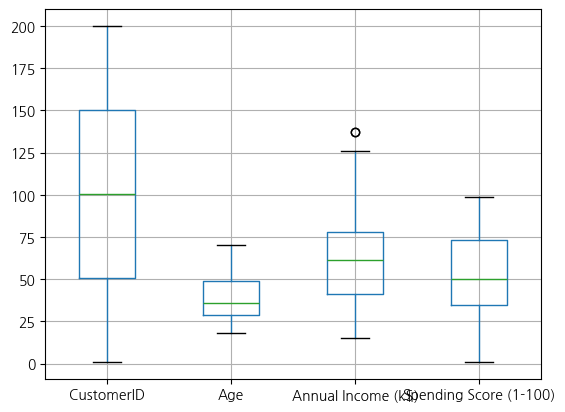

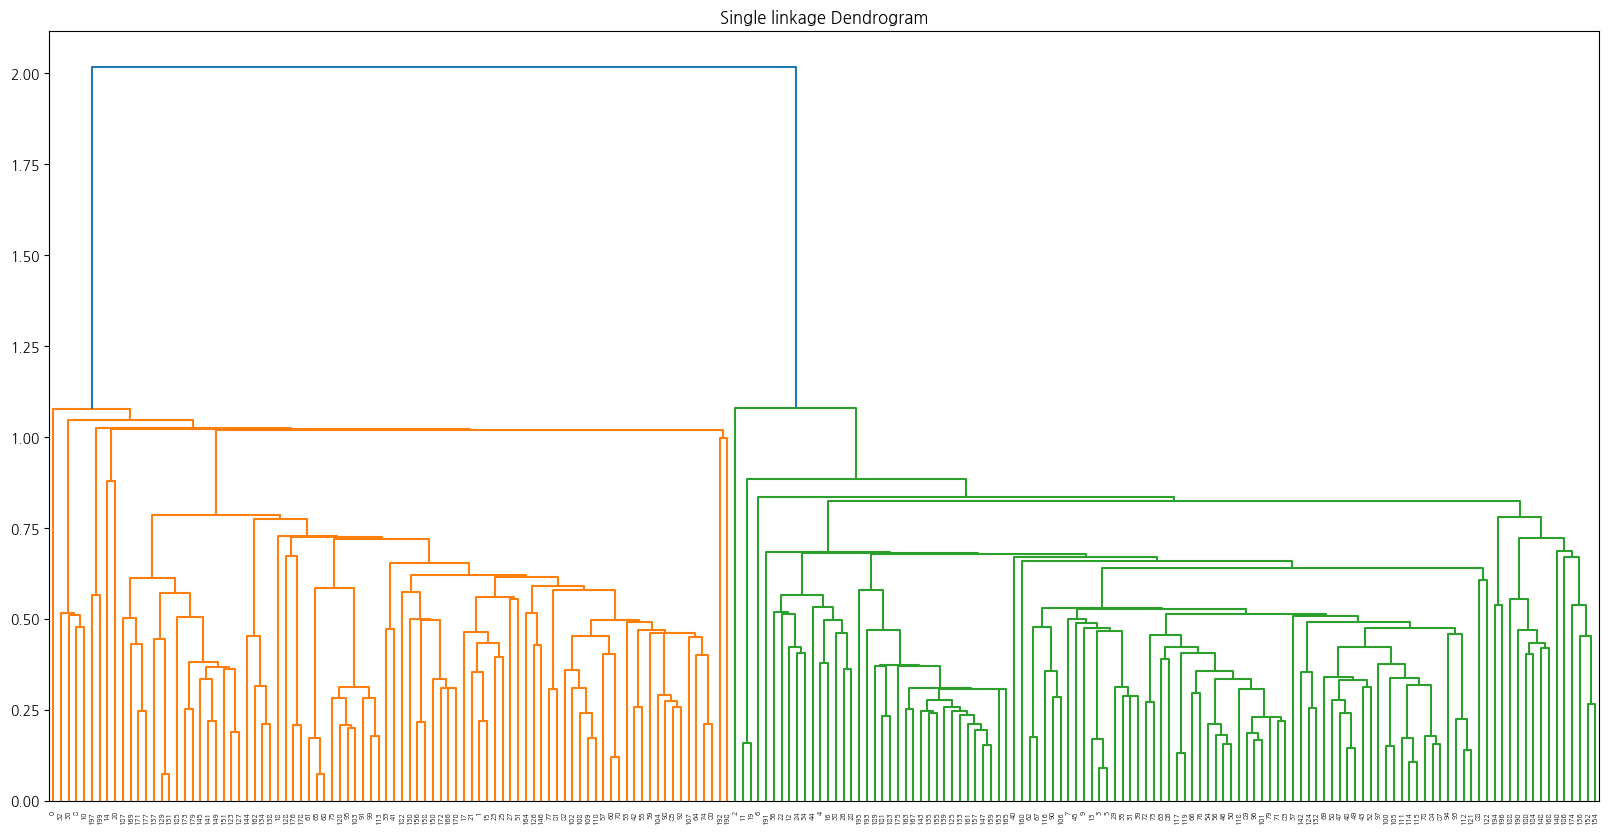

In [70]:
plt.figure(figsize=(20, 10))
plt.title('Single linkage Dendrogram')
dend = shc.dendrogram(shc.linkage(scaled_df, method='single'))
plt.show()

* 완전연결법(complete linkage) 최장연결법

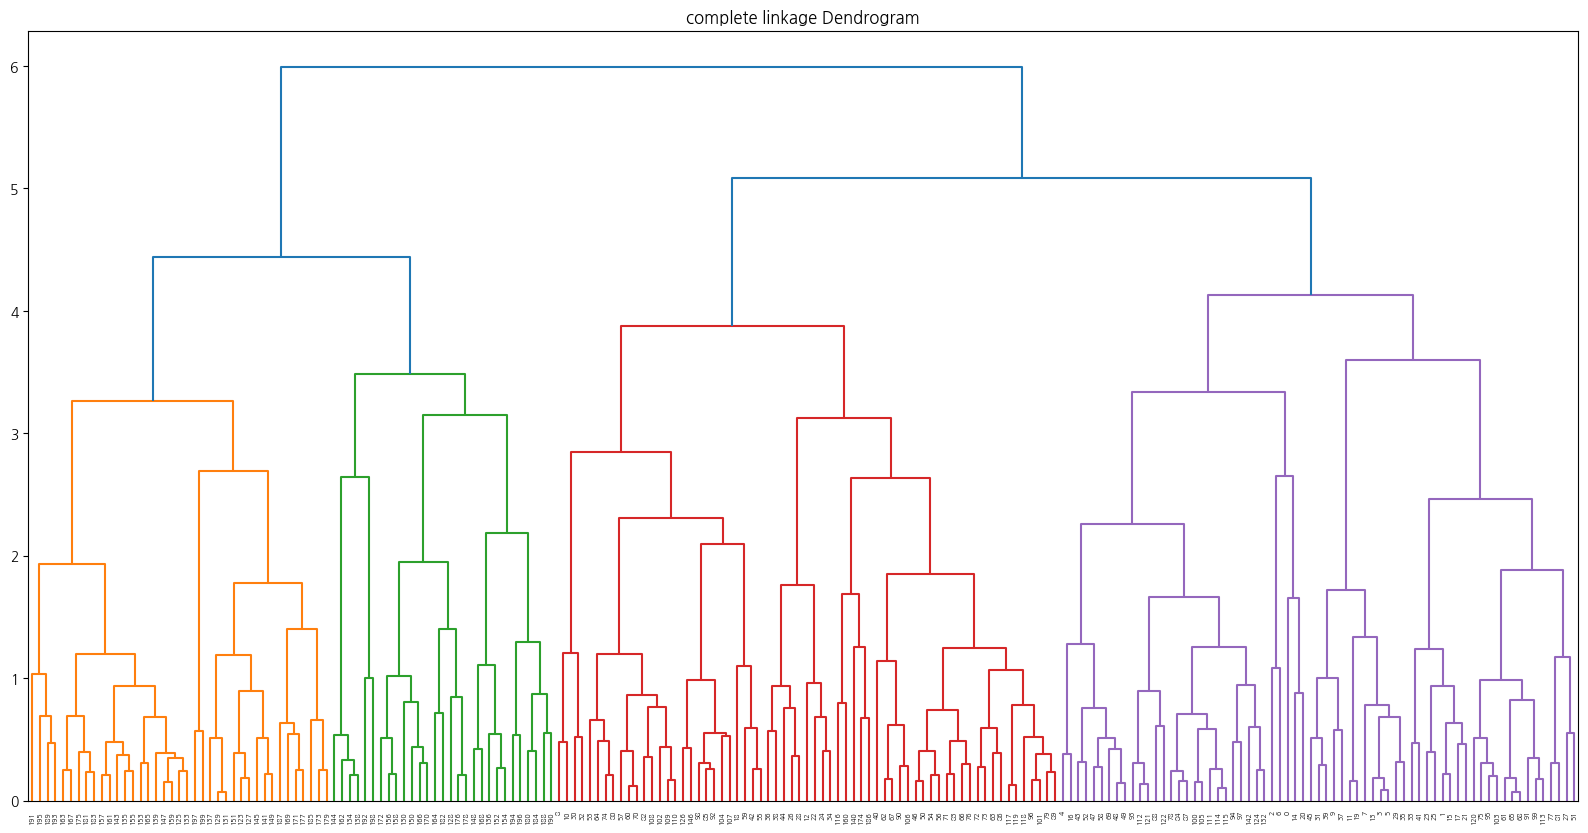

In [71]:
plt.figure(figsize=(20, 10))
plt.title('complete linkage Dendrogram')
dend = shc.dendrogram(shc.linkage(scaled_df, method='complete'))
plt.show()

* 평균연결법 (average linkage)

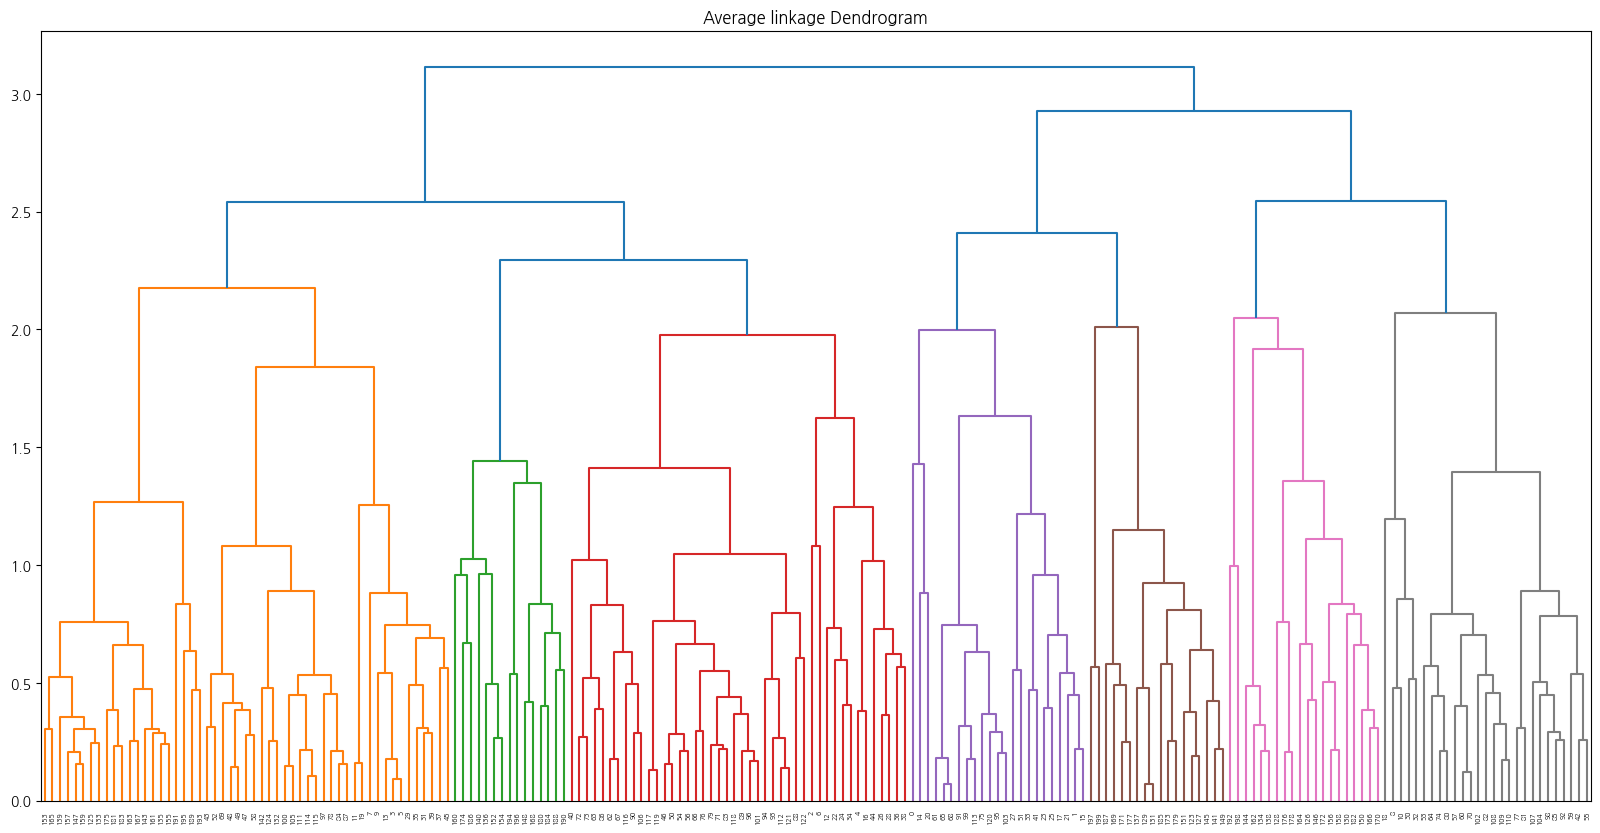

In [72]:
plt.figure(figsize=(20, 10))
plt.title('Average linkage Dendrogram')
dend = shc.dendrogram(shc.linkage(scaled_df, method='average'))
plt.show()

* 중심연결법 (centroid linkage)

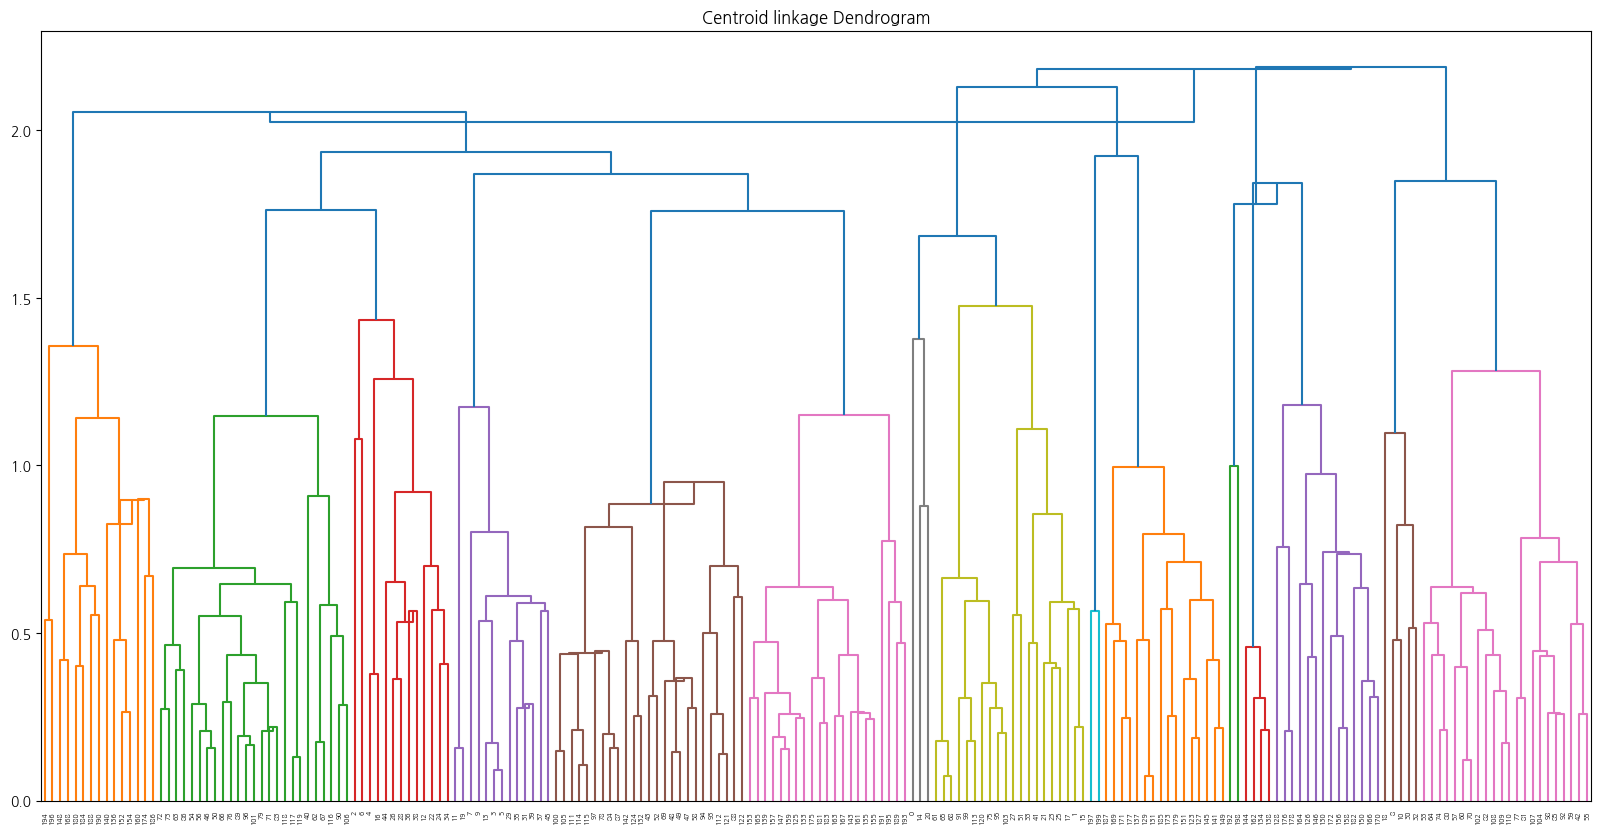

In [73]:
plt.figure(figsize=(20, 10))
plt.title('Centroid linkage Dendrogram')
dend = shc.dendrogram(shc.linkage(scaled_df, method='centroid'))
plt.show()

* 와드연결법 (ward linkage) - 군집 내 분산 최소화

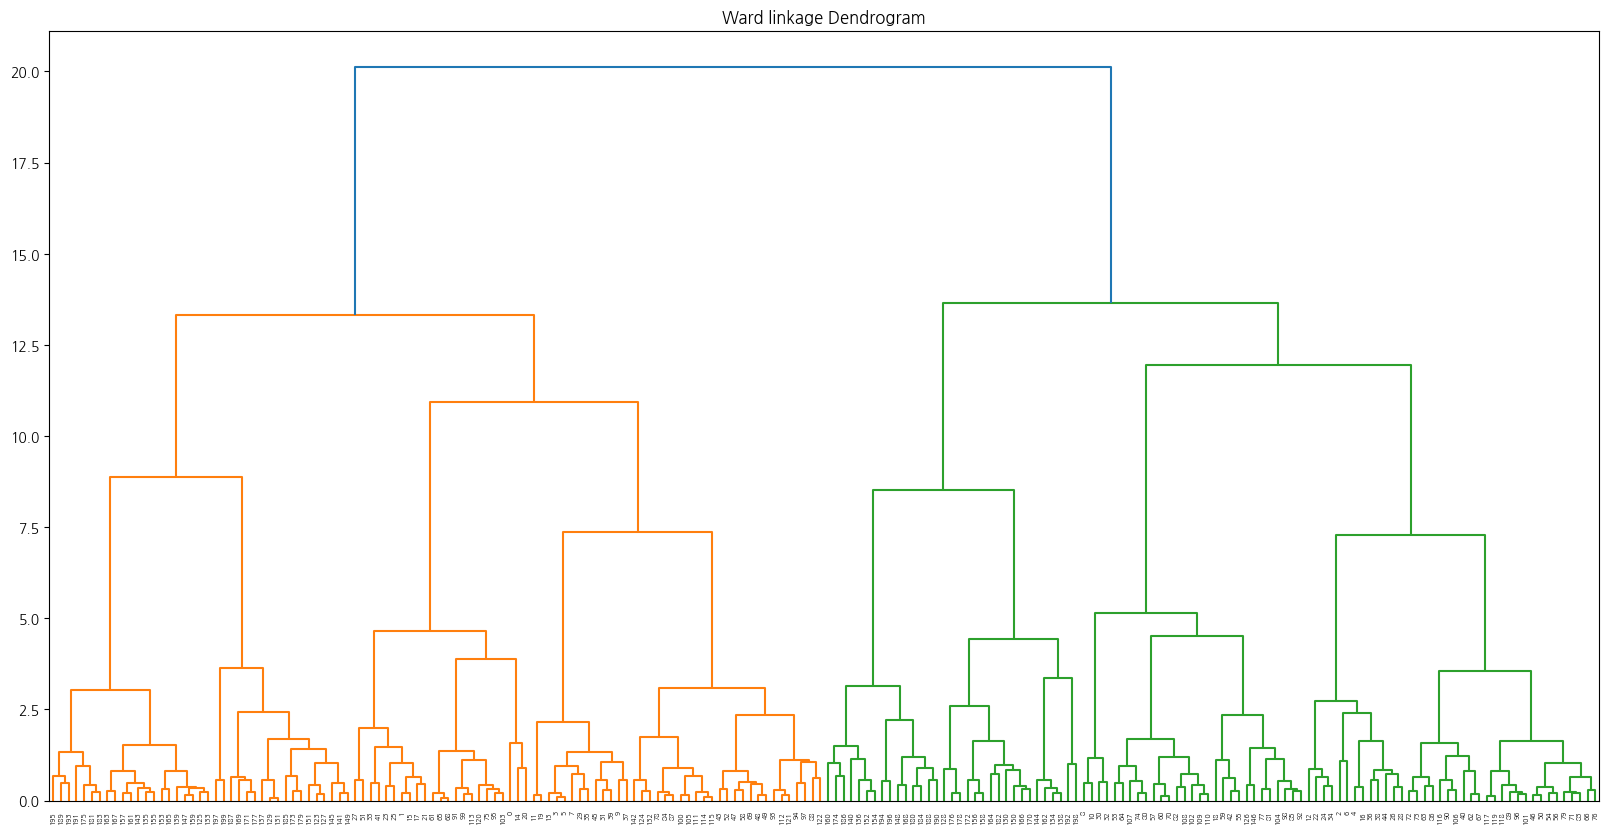

In [74]:
plt.figure(figsize=(20, 10))
plt.title('Ward linkage Dendrogram')
dend = shc.dendrogram(shc.linkage(scaled_df, method='ward'))
plt.show()

# scikit-learn을 이용한 계층군집

In [75]:
from sklearn.cluster import AgglomerativeClustering

In [76]:
single = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='single')
result = single.fit_predict(scaled_df)
result

array([0, 0, 1, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 0, 0, 2, 0, 0,
       2, 0, 2, 0, 2, 0, 2, 2, 0, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 0, 0, 2,
       2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 0, 0, 2, 2, 0, 0,
       2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 0, 2, 2, 0, 0, 0, 2, 2, 0, 2, 2,
       2, 2, 2, 0, 0, 2, 2, 0, 2, 2, 0, 0, 2, 2, 0, 0, 0, 2, 2, 0, 0, 0,
       0, 2, 2, 0, 2, 2, 2, 2, 2, 2, 0, 2, 2, 0, 2, 2, 0, 0, 0, 0, 0, 0,
       2, 2, 0, 2, 2, 0, 0, 2, 2, 0, 2, 2, 0, 0, 0, 2, 2, 0, 0, 0, 2, 2,
       2, 2, 0, 2, 0, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 0, 0, 0, 0, 2, 2,
       0, 0, 0, 0, 2, 2, 0, 2, 2, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 2, 0,
       0, 0])

In [77]:
data2['single'] = result
data2

,Age,Annual Income (k$),Spending Score (1-100),Genre_Male,single
0,19,15,39,True,0
1,21,15,81,True,0
2,20,16,6,False,1
3,23,16,77,False,2
4,31,17,40,False,2
...,...,...,...,...,...
195,35,120,79,False,2
196,45,126,28,False,2
197,32,126,74,True,0
198,32,137,18,True,0


In [78]:
# sklearn에는 centroid가 없다.
for linkage in ['complete', 'average', 'ward', 'single']:
    single = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage=linkage)
    result = single.fit_predict(scaled_df)
    data2[linkage] = result
    display(data2)

,Age,Annual Income (k$),Spending Score (1-100),Genre_Male,single,complete
0,19,15,39,True,0,1
1,21,15,81,True,0,1
2,20,16,6,False,1,1
3,23,16,77,False,2,1
4,31,17,40,False,2,1
...,...,...,...,...,...,...
195,35,120,79,False,2,0
196,45,126,28,False,2,0
197,32,126,74,True,0,0
198,32,137,18,True,0,0


,Age,Annual Income (k$),Spending Score (1-100),Genre_Male,single,complete,average
0,19,15,39,True,0,1,2
1,21,15,81,True,0,1,2
2,20,16,6,False,1,1,1
3,23,16,77,False,2,1,1
4,31,17,40,False,2,1,1
...,...,...,...,...,...,...,...
195,35,120,79,False,2,0,1
196,45,126,28,False,2,0,1
197,32,126,74,True,0,0,2
198,32,137,18,True,0,0,0


,Age,Annual Income (k$),Spending Score (1-100),Genre_Male,single,complete,average,ward
0,19,15,39,True,0,1,2,0
1,21,15,81,True,0,1,2,0
2,20,16,6,False,1,1,1,1
3,23,16,77,False,2,1,1,0
4,31,17,40,False,2,1,1,1
...,...,...,...,...,...,...,...,...
195,35,120,79,False,2,0,1,0
196,45,126,28,False,2,0,1,2
197,32,126,74,True,0,0,2,0
198,32,137,18,True,0,0,0,2


,Age,Annual Income (k$),Spending Score (1-100),Genre_Male,single,complete,average,ward
0,19,15,39,True,0,1,2,0
1,21,15,81,True,0,1,2,0
2,20,16,6,False,1,1,1,1
3,23,16,77,False,2,1,1,0
4,31,17,40,False,2,1,1,1
...,...,...,...,...,...,...,...,...
195,35,120,79,False,2,0,1,0
196,45,126,28,False,2,0,1,2
197,32,126,74,True,0,0,2,0
198,32,137,18,True,0,0,0,2


In [79]:
data2

,Age,Annual Income (k$),Spending Score (1-100),Genre_Male,single,complete,average,ward
0,19,15,39,True,0,1,2,0
1,21,15,81,True,0,1,2,0
2,20,16,6,False,1,1,1,1
3,23,16,77,False,2,1,1,0
4,31,17,40,False,2,1,1,1
...,...,...,...,...,...,...,...,...
195,35,120,79,False,2,0,1,0
196,45,126,28,False,2,0,1,2
197,32,126,74,True,0,0,2,0
198,32,137,18,True,0,0,0,2


In [80]:
data2[data2['single'] == 0].describe()

,Age,Annual Income (k$),Spending Score (1-100),single,complete,average,ward
count,88.000000,88.000000,88.000000,88.0,88.000000,88.000000,88.000000
mean,39.806818,62.227273,48.511364,0.0,0.897727,0.931818,0.738636
std,15.514812,26.638373,27.896770,0.0,0.844724,1.003390,0.780426
min,18.000000,15.000000,1.000000,0.0,0.000000,0.000000,0.000000
25%,27.750000,45.500000,24.500000,0.0,0.000000,0.000000,0.000000
50%,37.000000,62.500000,50.000000,0.0,1.000000,0.000000,1.000000
75%,50.500000,78.000000,70.000000,0.0,2.000000,2.000000,1.000000
max,70.000000,137.000000,97.000000,0.0,2.000000,2.000000,2.000000


In [81]:
data2[data2['single'] == 2].describe()

,Age,Annual Income (k$),Spending Score (1-100),single,complete,average,ward
count,111.000000,111.000000,111.000000,111.0,111.000000,111.0,111.000000
mean,38.261261,59.639640,51.936937,2.0,1.054054,1.0,0.603604
std,12.582608,25.799504,23.828661,0.0,0.795874,0.0,0.717056
min,18.000000,16.000000,5.000000,2.0,0.000000,1.0,0.000000
25%,29.500000,40.000000,37.000000,2.0,0.000000,1.0,0.000000
50%,35.000000,60.000000,50.000000,2.0,1.000000,1.0,0.000000
75%,48.000000,77.500000,73.000000,2.0,2.000000,1.0,1.000000
max,68.000000,126.000000,99.000000,2.0,2.000000,1.0,2.000000


In [82]:
data2[data2['average'] == 0].describe()
# 수입이 높은데 소비를 적게 함

,Age,Annual Income (k$),Spending Score (1-100),single,complete,average,ward
count,47.000000,47.000000,47.000000,47.0,47.000000,47.0,47.000000
mean,49.765957,63.957447,29.978723,0.0,1.191489,0.0,1.382979
std,13.997225,23.475202,19.664014,0.0,0.969946,0.0,0.491369
min,19.000000,19.000000,1.000000,0.0,0.000000,0.0,1.000000
25%,41.000000,48.500000,11.500000,0.0,0.000000,0.0,1.000000
50%,49.000000,63.000000,35.000000,0.0,2.000000,0.0,1.000000
75%,59.500000,78.000000,47.500000,0.0,2.000000,0.0,2.000000
max,70.000000,137.000000,60.000000,0.0,2.000000,0.0,2.000000


In [83]:
data2[data2['average'] == 1].describe()

,Age,Annual Income (k$),Spending Score (1-100),single,complete,average,ward
count,112.000000,112.000000,112.000000,112.000000,112.000000,112.0,112.000000
mean,38.098214,59.250000,51.526786,1.991071,1.053571,1.0,0.607143
std,12.644095,26.011952,24.114950,0.094491,0.792297,0.0,0.714800
min,18.000000,16.000000,5.000000,1.000000,0.000000,1.0,0.000000
25%,29.000000,39.750000,35.000000,2.000000,0.000000,1.0,0.000000
50%,35.000000,60.000000,50.000000,2.000000,1.000000,1.0,0.000000
75%,47.500000,77.250000,73.000000,2.000000,2.000000,1.0,1.000000
max,68.000000,126.000000,99.000000,2.000000,2.000000,1.0,2.000000


In [84]:
data2[data2['average'] == 2].describe()
# 수입이 높고, 소비를 많이 함

,Age,Annual Income (k$),Spending Score (1-100),single,complete,average,ward
count,41.000000,41.000000,41.000000,41.0,41.000000,41.0,41.0
mean,28.390244,60.243902,69.756098,0.0,0.560976,2.0,0.0
std,6.934977,30.034797,19.539422,0.0,0.502433,0.0,0.0
min,18.000000,15.000000,13.000000,0.0,0.000000,2.0,0.0
25%,22.000000,33.000000,56.000000,0.0,0.000000,2.0,0.0
50%,28.000000,62.000000,73.000000,0.0,1.000000,2.0,0.0
75%,34.000000,78.000000,88.000000,0.0,1.000000,2.0,0.0
max,40.000000,137.000000,97.000000,0.0,1.000000,2.0,0.0


# 비계층적 군집 - 데이터 수가 많을 떄 사용
* k-means(k 평균 군집): 거리를 기반으로 군집을 형성, 이상치에 민감함
* StandardScaler 사용, 데이터에 이상치가 있으면 RobustScalar 사용
* 이상치가 많은 경우 평균이 아닌 중앙값을 이용해서 군집 형성
* k의 개수 구하는 것이 튜닝

In [85]:
data = pd.read_csv('./data/고객이탈예측.csv', encoding='cp949')
data

,회원ID,성별,고연령,배우자,피부양자,가입기간,전화서비스,2회선이상,인터넷서비스,온라인보안,...,기기보호서비스,기술지원,스트리밍TV,스트리밍Movies,약정옵션,온라인고지서,지불수단,월요금,합산요금,이탈여부
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [86]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   회원ID        7043 non-null   str    
 1   성별          7043 non-null   str    
 2   고연령         7043 non-null   int64  
 3   배우자         7043 non-null   str    
 4   피부양자        7043 non-null   str    
 5   가입기간        7043 non-null   int64  
 6   전화서비스       7043 non-null   str    
 7   2회선이상       7043 non-null   str    
 8   인터넷서비스      7043 non-null   str    
 9   온라인보안       7043 non-null   str    
 10  온라인백업       7043 non-null   str    
 11  기기보호서비스     7043 non-null   str    
 12  기술지원        7043 non-null   str    
 13  스트리밍TV      7043 non-null   str    
 14  스트리밍Movies  7043 non-null   str    
 15  약정옵션        7043 non-null   str    
 16  온라인고지서      7043 non-null   str    
 17  지불수단        7043 non-null   str    
 18  월요금         7043 non-null   float64
 19  합산요금        7043 non-null   str    
 2

### 데이터 정제 확인
* 결측값 없음
* 결측값 채우는 거 강의 보강해야 함
* 합산요금: 숫자로 바꿔야 함

In [87]:
# data['합산요금'].astype(float)
# 합산요금의 ' ' 값을 월요금으로 대체하기

data.loc[data['합산요금'] == ' ', ['합산요금']] = data.loc[data['합산요금'] == ' ', ['월요금']]

In [88]:
hap_price = list(data.loc[data['합산요금'] == ' ', '합산요금'])

In [89]:
missing_idx = data.loc[data['합산요금'] == ' ', '합산요금'].index

In [90]:
data.ioc[missing_idx]['합산요금'] = hap_price

AttributeError: 'DataFrame' object has no attribute 'ioc'

In [91]:
data2 = data.drop('회원ID', axis=1)
data2

,성별,고연령,배우자,피부양자,가입기간,전화서비스,2회선이상,인터넷서비스,온라인보안,온라인백업,기기보호서비스,기술지원,스트리밍TV,스트리밍Movies,약정옵션,온라인고지서,지불수단,월요금,합산요금,이탈여부
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [93]:
data.loc[data['합산요금'] == ' ', ['합산요금']] # 없어진 거 확인

,합산요금


In [94]:
data['합산요금'].value_counts()

합산요금
20.2      11
19.75      9
19.9       8
20.05      8
19.65      8
          ..
1990.5     1
7362.9     1
346.45     1
306.6      1
6844.5     1
Name: count, Length: 6530, dtype: int64

* 범주형 변수를 one-hot encoding

In [92]:
data2 = pd.get_dummies(data2, drop_first=True)
data2

,고연령,가입기간,월요금,성별_Male,배우자_Yes,피부양자_Yes,전화서비스_Yes,2회선이상_No phone service,2회선이상_Yes,인터넷서비스_Fiber optic,...,합산요금_996.45,합산요금_996.85,합산요금_996.95,합산요금_997.65,합산요금_997.75,합산요금_998.1,합산요금_999.45,합산요금_999.8,합산요금_999.9,이탈여부_Yes
0,0,1,29.85,False,True,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,0,34,56.95,True,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,0,2,53.85,True,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,0,45,42.30,True,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
4,0,2,70.70,False,False,False,True,False,False,True,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,True,True,True,True,False,True,False,...,False,False,False,False,False,False,False,False,False,False
7039,0,72,103.20,False,True,True,True,False,True,True,...,False,False,False,False,False,False,False,False,False,False
7040,0,11,29.60,False,True,True,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
7041,1,4,74.40,True,True,False,True,False,True,True,...,False,False,False,False,False,False,False,False,False,True


* standard scalar를 이용해 스케일 맞추기

In [95]:
from sklearn.preprocessing import StandardScaler

In [97]:
ss = StandardScaler()
scaled_df = ss.fit_transform(data2)
scaled_df = pd.DataFrame(scaled_df, index=data2.index, columns=data2.columns)
scaled_df

,고연령,가입기간,월요금,성별_Male,배우자_Yes,피부양자_Yes,전화서비스_Yes,2회선이상_No phone service,2회선이상_Yes,인터넷서비스_Fiber optic,...,합산요금_996.45,합산요금_996.85,합산요금_996.95,합산요금_997.65,합산요금_997.75,합산요금_998.1,합산요금_999.45,합산요금_999.8,합산요금_999.9,이탈여부_Yes
0,-0.439916,-1.277445,-1.160323,-1.009559,1.034530,-0.654012,-3.054010,3.054010,-0.854176,-0.885660,...,-0.011917,-0.011917,-0.011917,-0.011917,-0.011917,-0.011917,-0.011917,-0.011917,-0.011917,-0.601023
1,-0.439916,0.066327,-0.259629,0.990532,-0.966622,-0.654012,0.327438,-0.327438,-0.854176,-0.885660,...,-0.011917,-0.011917,-0.011917,-0.011917,-0.011917,-0.011917,-0.011917,-0.011917,-0.011917,-0.601023
2,-0.439916,-1.236724,-0.362660,0.990532,-0.966622,-0.654012,0.327438,-0.327438,-0.854176,-0.885660,...,-0.011917,-0.011917,-0.011917,-0.011917,-0.011917,-0.011917,-0.011917,-0.011917,-0.011917,1.663829
3,-0.439916,0.514251,-0.746535,0.990532,-0.966622,-0.654012,-3.054010,3.054010,-0.854176,-0.885660,...,-0.011917,-0.011917,-0.011917,-0.011917,-0.011917,-0.011917,-0.011917,-0.011917,-0.011917,-0.601023
4,-0.439916,-1.236724,0.197365,-1.009559,-0.966622,-0.654012,0.327438,-0.327438,-0.854176,1.129102,...,-0.011917,-0.011917,-0.011917,-0.011917,-0.011917,-0.011917,-0.011917,-0.011917,-0.011917,1.663829
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,-0.439916,-0.340876,0.665992,0.990532,1.034530,1.529024,0.327438,-0.327438,1.170719,-0.885660,...,-0.011917,-0.011917,-0.011917,-0.011917,-0.011917,-0.011917,-0.011917,-0.011917,-0.011917,-0.601023
7039,-0.439916,1.613701,1.277533,-1.009559,1.034530,1.529024,0.327438,-0.327438,1.170719,1.129102,...,-0.011917,-0.011917,-0.011917,-0.011917,-0.011917,-0.011917,-0.011917,-0.011917,-0.011917,-0.601023
7040,-0.439916,-0.870241,-1.168632,-1.009559,1.034530,1.529024,-3.054010,3.054010,-0.854176,-0.885660,...,-0.011917,-0.011917,-0.011917,-0.011917,-0.011917,-0.011917,-0.011917,-0.011917,-0.011917,-0.601023
7041,2.273159,-1.155283,0.320338,0.990532,1.034530,-0.654012,0.327438,-0.327438,1.170719,1.129102,...,-0.011917,-0.011917,-0.011917,-0.011917,-0.011917,-0.011917,-0.011917,-0.011917,-0.011917,1.663829


# K-means로 군집 분석

In [98]:
from sklearn.cluster import KMeans

In [99]:
# KMeans의 기본 n_clusters-8
km = KMeans(random_state=42)
km.fit(scaled_df)
result = km.labels_
result

array([2, 2, 2, ..., 2, 2, 2], shape=(7043,), dtype=int32)

In [100]:
data2['cluster8'] = result
data2

,고연령,가입기간,월요금,성별_Male,배우자_Yes,피부양자_Yes,전화서비스_Yes,2회선이상_No phone service,2회선이상_Yes,인터넷서비스_Fiber optic,...,합산요금_996.85,합산요금_996.95,합산요금_997.65,합산요금_997.75,합산요금_998.1,합산요금_999.45,합산요금_999.8,합산요금_999.9,이탈여부_Yes,cluster8
0,0,1,29.85,False,True,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,2
1,0,34,56.95,True,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,2
2,0,2,53.85,True,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,True,2
3,0,45,42.30,True,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,2
4,0,2,70.70,False,False,False,True,False,False,True,...,False,False,False,False,False,False,False,False,True,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,True,True,True,True,False,True,False,...,False,False,False,False,False,False,False,False,False,2
7039,0,72,103.20,False,True,True,True,False,True,True,...,False,False,False,False,False,False,False,False,False,2
7040,0,11,29.60,False,True,True,False,True,False,False,...,False,False,False,False,False,False,False,False,False,2
7041,1,4,74.40,True,True,False,True,False,True,True,...,False,False,False,False,False,False,False,False,True,2


In [103]:
data2['cluster8'].value_counts()

cluster8
2    7035
7       2
3       1
4       1
0       1
5       1
6       1
1       1
Name: count, dtype: int64

In [104]:
data2[data2['cluster8'] == 7]

,고연령,가입기간,월요금,성별_Male,배우자_Yes,피부양자_Yes,전화서비스_Yes,2회선이상_No phone service,2회선이상_Yes,인터넷서비스_Fiber optic,...,합산요금_996.85,합산요금_996.95,합산요금_997.65,합산요금_997.75,합산요금_998.1,합산요금_999.45,합산요금_999.8,합산요금_999.9,이탈여부_Yes,cluster8
1407,0,8,44.55,True,False,True,False,True,False,False,...,False,False,False,False,False,False,False,False,False,7
6431,0,17,19.15,True,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,7


In [105]:
data2[data2['cluster8'] == 7]['이탈여부_Yes'].value_counts()

이탈여부_Yes
False    2
Name: count, dtype: int64

In [106]:
data2[data2['cluster8'] == 7].describe(include='all')

,고연령,가입기간,월요금,성별_Male,배우자_Yes,피부양자_Yes,전화서비스_Yes,2회선이상_No phone service,2회선이상_Yes,인터넷서비스_Fiber optic,...,합산요금_996.85,합산요금_996.95,합산요금_997.65,합산요금_997.75,합산요금_998.1,합산요금_999.45,합산요금_999.8,합산요금_999.9,이탈여부_Yes,cluster8
count,2.0,2.000000,2.000000,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2.0
unique,NaN,NaN,NaN,1,1,2,2,2,1,1,...,1,1,1,1,1,1,1,1,1,NaN
top,NaN,NaN,NaN,True,False,True,False,True,False,False,...,False,False,False,False,False,False,False,False,False,NaN
freq,NaN,NaN,NaN,2,2,1,1,1,2,2,...,2,2,2,2,2,2,2,2,2,NaN
mean,0.0,12.500000,31.850000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0
std,0.0,6.363961,17.960512,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
min,0.0,8.000000,19.150000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0
25%,0.0,10.250000,25.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0
50%,0.0,12.500000,31.850000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0
75%,0.0,14.750000,38.200000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0


# 군집의 최적 개수 정하기
* elbow method
* 실루엣 지수
* 군집분석 응집도 (요소들이 얼마나 보여있는지 판단하는 지표
    * 응집도가 높다 => 분산이 작다
    * 응집도가 낮다 => 분산이 크다
    * inertia_ 값이 작을수록 군집이 잘 형성됨
* elbow_method: inertia (응집도)를 출력하고 시각화 한 뒤 응집도의 감소폭이 급격한 변화가 시작되는 지점을 최적 군집의 수로 채택

In [107]:
print(km.inertia_)

46145489.94155136


# n_cluster를 1-20까지 변경하면서 inertia_ 출력 후 비교

In [112]:
inertia = []
for i in range(1, 21):
    km = KMeans(n_clusters=i, random_state=42)
    km.fit(scaled_df)
    inertia.append(km.inertia_)
inertia

[46195036.999999255,
 46123487.20014161,
 46180882.89638581,
 46173805.97581206,
 46166730.99190301,
 46159651.65205856,
 46152580.24933858,
 46145489.94155136,
 46138405.001957044,
 46131335.900146626,
 46124266.08980115,
 46117175.22373774,
 46110107.965796754,
 46103036.21459958,
 46095919.99210863,
 46088853.58380552,
 46081786.079084545,
 46074701.38558835,
 46067624.2055165,
 46060537.52174467]

In [110]:
import seaborn as sns

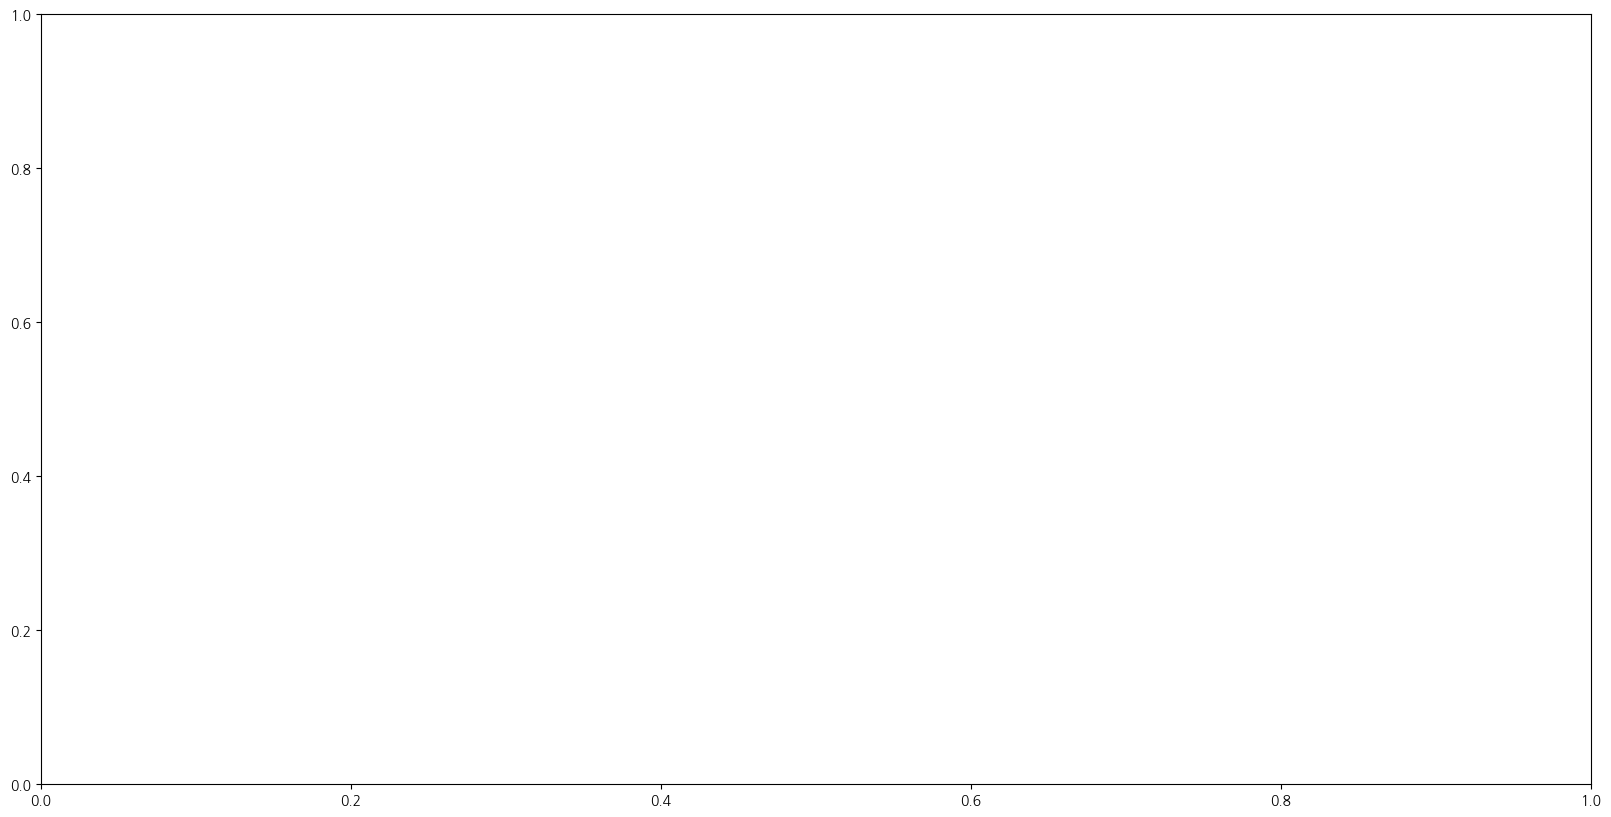

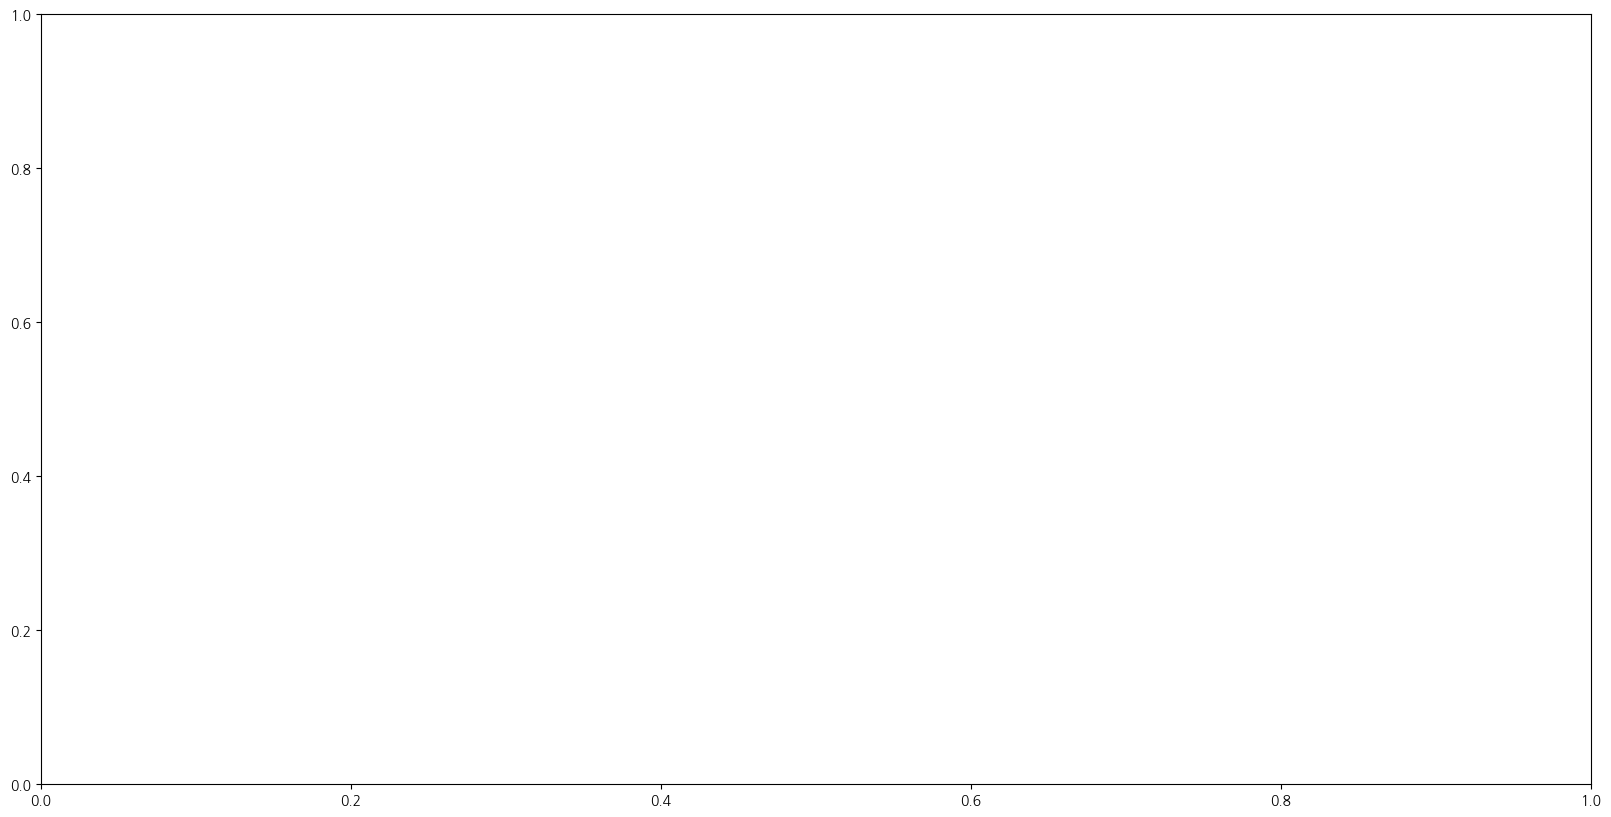

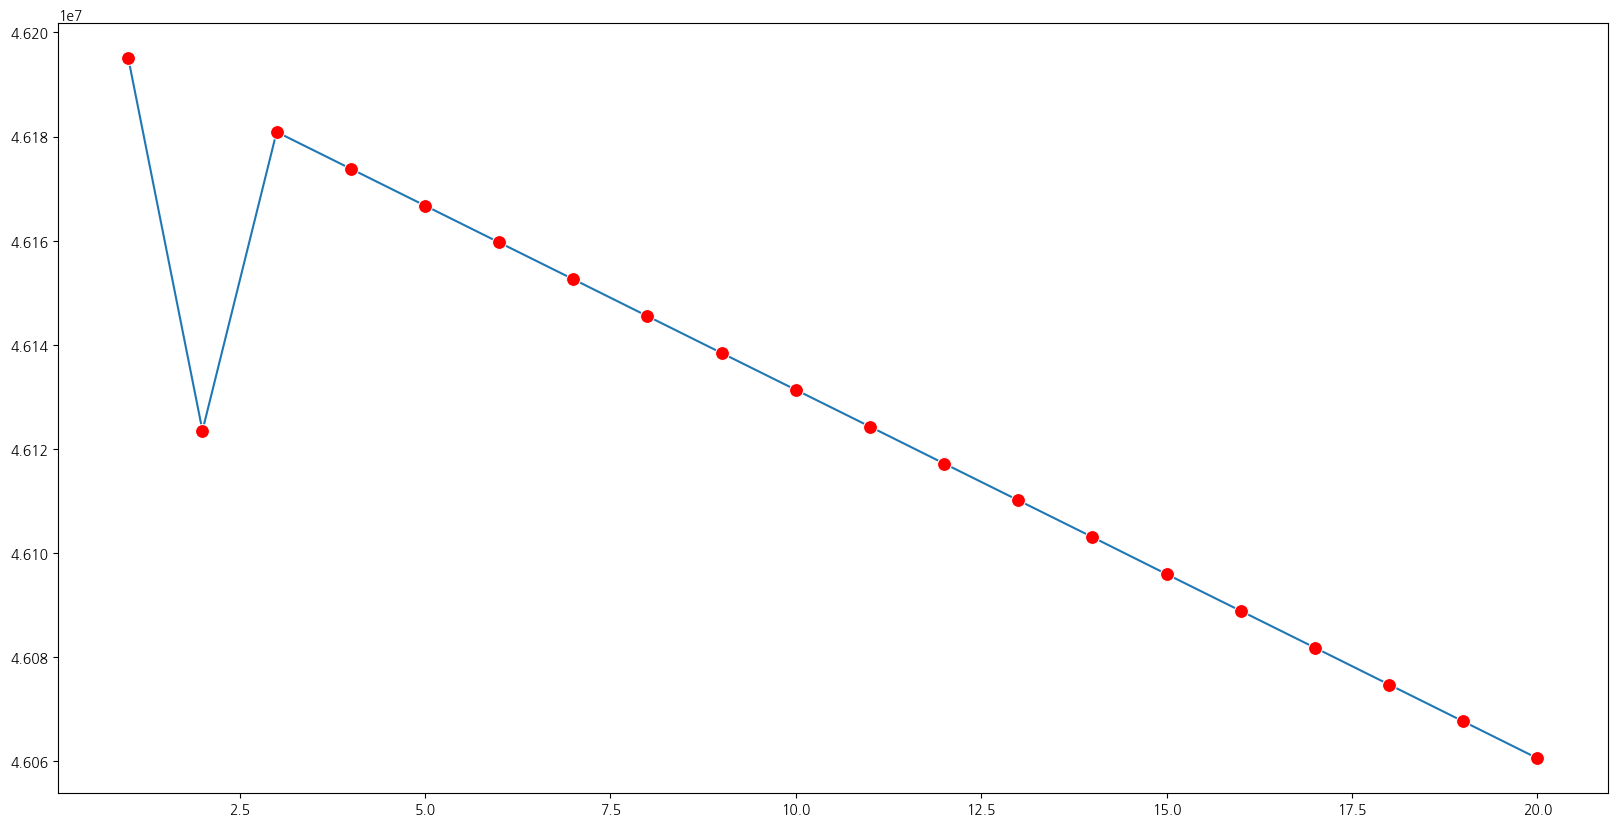

In [114]:
plt.figure(figsize=(20,10))
sns.lineplot(x=range(1, 21), y=inertia, marker='o', markersize=10, markerfacecolor='red')
plt.show()

In [116]:
# KMeans의 기본 n_clusters-8
km = KMeans(n_clusters=4, random_state=42)
km.fit(scaled_df)
result = km.labels_
result

array([2, 2, 2, ..., 2, 2, 2], shape=(7043,), dtype=int32)

In [120]:
data2['cluster4'] = result
data2

,고연령,가입기간,월요금,성별_Male,배우자_Yes,피부양자_Yes,전화서비스_Yes,2회선이상_No phone service,2회선이상_Yes,인터넷서비스_Fiber optic,...,합산요금_996.95,합산요금_997.65,합산요금_997.75,합산요금_998.1,합산요금_999.45,합산요금_999.8,합산요금_999.9,이탈여부_Yes,cluster8,cluster4
0,0,1,29.85,False,True,False,False,True,False,False,...,False,False,False,False,False,False,False,False,2,2
1,0,34,56.95,True,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,2,2
2,0,2,53.85,True,False,False,True,False,False,False,...,False,False,False,False,False,False,False,True,2,2
3,0,45,42.30,True,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,2,2
4,0,2,70.70,False,False,False,True,False,False,True,...,False,False,False,False,False,False,False,True,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,True,True,True,True,False,True,False,...,False,False,False,False,False,False,False,False,2,2
7039,0,72,103.20,False,True,True,True,False,True,True,...,False,False,False,False,False,False,False,False,2,2
7040,0,11,29.60,False,True,True,False,True,False,False,...,False,False,False,False,False,False,False,False,2,2
7041,1,4,74.40,True,True,False,True,False,True,True,...,False,False,False,False,False,False,False,True,2,2


In [121]:
data2['cluster4'].value_counts()

cluster4
2    7040
0       1
1       1
3       1
Name: count, dtype: int64

In [124]:
data2[data2['cluster4'] == 3]

,고연령,가입기간,월요금,성별_Male,배우자_Yes,피부양자_Yes,전화서비스_Yes,2회선이상_No phone service,2회선이상_Yes,인터넷서비스_Fiber optic,...,합산요금_996.95,합산요금_997.65,합산요금_997.75,합산요금_998.1,합산요금_999.45,합산요금_999.8,합산요금_999.9,이탈여부_Yes,cluster8,cluster4
6105,0,52,111.25,False,False,False,True,False,True,True,...,False,False,False,False,False,False,False,True,2,3


In [126]:
data2[data2['cluster4'] == 2].describe(include='all')

,고연령,가입기간,월요금,성별_Male,배우자_Yes,피부양자_Yes,전화서비스_Yes,2회선이상_No phone service,2회선이상_Yes,인터넷서비스_Fiber optic,...,합산요금_996.95,합산요금_997.65,합산요금_997.75,합산요금_998.1,합산요금_999.45,합산요금_999.8,합산요금_999.9,이탈여부_Yes,cluster8,cluster4
count,7040.000000,7040.000000,7040.000000,7040,7040,7040,7040,7040,7040,7040,...,7040,7040,7040,7040,7040,7040,7040,7040,7040.000000,7040.0
unique,NaN,NaN,NaN,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,NaN,NaN
top,NaN,NaN,NaN,True,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,NaN,NaN
freq,NaN,NaN,NaN,3554,3640,4931,6359,6359,4071,3946,...,7039,7039,7039,7039,7039,7039,7039,5172,NaN,NaN
mean,0.162074,32.370455,64.757045,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.002841,2.0
std,0.368545,24.562586,30.089732,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.106570,0.0
min,0.000000,0.000000,18.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,2.0
25%,0.000000,9.000000,35.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,2.0
50%,0.000000,29.000000,70.350000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,2.0
75%,0.000000,55.000000,89.850000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,2.0


# 실루엣 지수를 출력해서 최적 군집 개수 구하기
* 실루엣 지수를 구하기 위해서는 최소 2개 이상의 군집이 필요
* 실루엣 지수가 가장 높은 클러스터 개수가 최적 군집 개수(1에 가까울수록 좋음)

In [127]:
from sklearn.metrics import silhouette_score

In [128]:
sil_scores = []
for i in range(2, 21):
    km2 = KMeans(n_clusters=i, random_state=42)
    km2.fit(scaled_df)
    labels = km2.labels_
    sil_scores.append(silhouette_score(scaled_df, labels))
sil_scores

[-0.010317308270046214,
 0.0206584303608797,
 0.02054658030653188,
 0.020480569902538923,
 0.02045538728764607,
 0.020430102356791675,
 -0.12185384558772684,
 -0.12183473723153697,
 -0.12279119044292824,
 -0.12277196720408377,
 -0.12275281248989858,
 -0.12273369323451713,
 -0.12256210975815393,
 -0.2040011223939218,
 -0.20369354725711686,
 -0.20366373018688058,
 -0.20363401570394657,
 -0.20333976104471932,
 -0.20330986602152978]

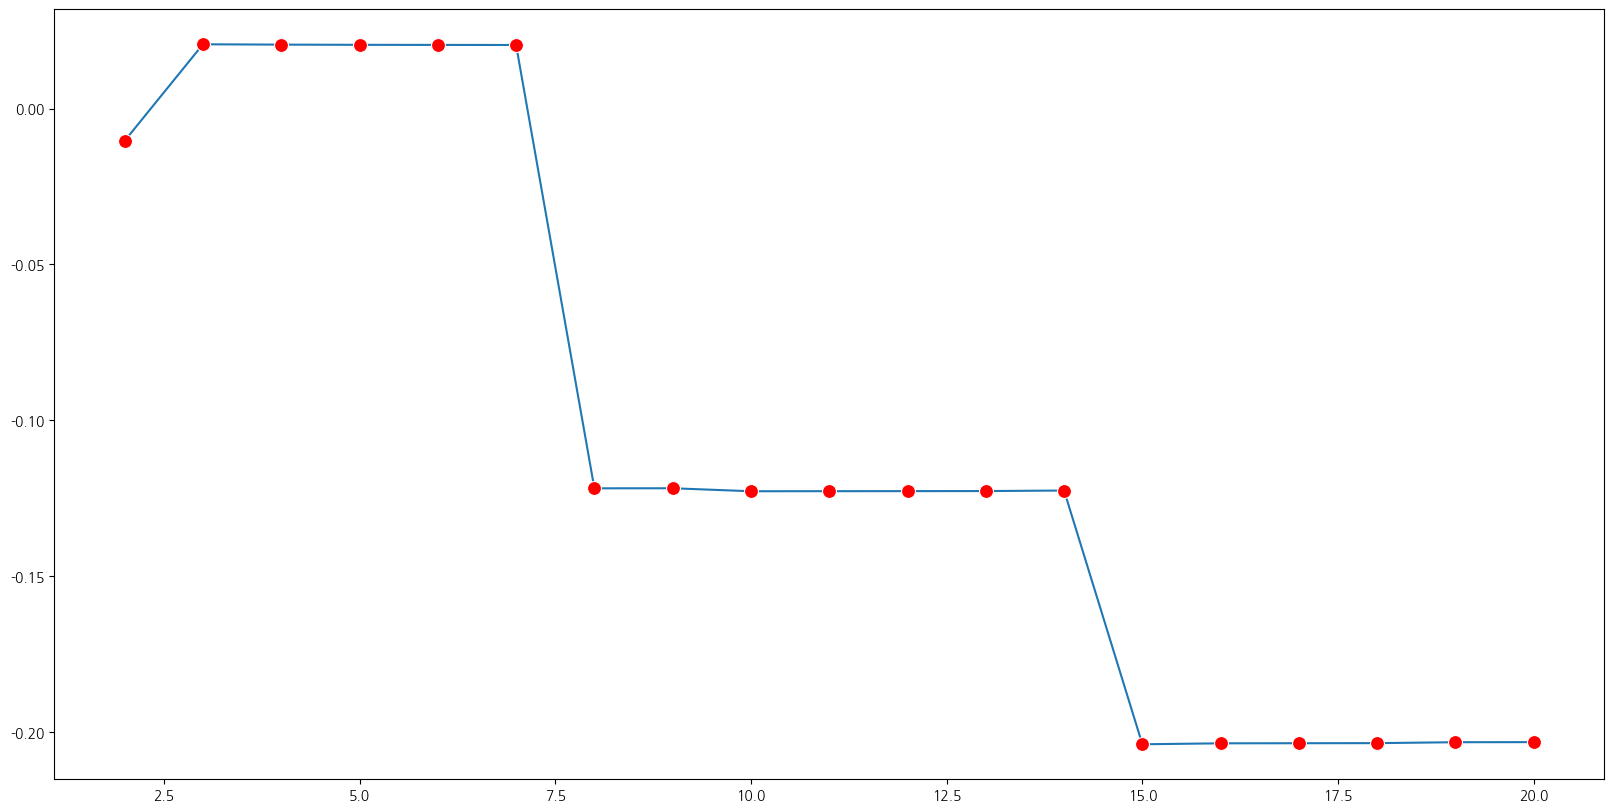

In [129]:
plt.figure(figsize=(20,10))
sns.lineplot(x=range(2, 21), y=sil_scores, marker='o', markersize=10, markerfacecolor='red')
plt.show()

In [130]:
km2 = KMeans(n_clusters=2, random_state=42)
km2.fit(scaled_df)
result = km2.labels_
result

array([1, 1, 1, ..., 1, 1, 1], shape=(7043,), dtype=int32)

In [131]:
data2['clusters2'] = result
data2

,고연령,가입기간,월요금,성별_Male,배우자_Yes,피부양자_Yes,전화서비스_Yes,2회선이상_No phone service,2회선이상_Yes,인터넷서비스_Fiber optic,...,합산요금_997.65,합산요금_997.75,합산요금_998.1,합산요금_999.45,합산요금_999.8,합산요금_999.9,이탈여부_Yes,cluster8,cluster4,clusters2
0,0,1,29.85,False,True,False,False,True,False,False,...,False,False,False,False,False,False,False,2,2,1
1,0,34,56.95,True,False,False,True,False,False,False,...,False,False,False,False,False,False,False,2,2,1
2,0,2,53.85,True,False,False,True,False,False,False,...,False,False,False,False,False,False,True,2,2,1
3,0,45,42.30,True,False,False,False,True,False,False,...,False,False,False,False,False,False,False,2,2,1
4,0,2,70.70,False,False,False,True,False,False,True,...,False,False,False,False,False,False,True,2,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,True,True,True,True,False,True,False,...,False,False,False,False,False,False,False,2,2,1
7039,0,72,103.20,False,True,True,True,False,True,True,...,False,False,False,False,False,False,False,2,2,1
7040,0,11,29.60,False,True,True,False,True,False,False,...,False,False,False,False,False,False,False,2,2,1
7041,1,4,74.40,True,True,False,True,False,True,True,...,False,False,False,False,False,False,True,2,2,1


In [135]:
data2[data2['clusters2'] == 0]

,고연령,가입기간,월요금,성별_Male,배우자_Yes,피부양자_Yes,전화서비스_Yes,2회선이상_No phone service,2회선이상_Yes,인터넷서비스_Fiber optic,...,합산요금_997.65,합산요금_997.75,합산요금_998.1,합산요금_999.45,합산요금_999.8,합산요금_999.9,이탈여부_Yes,cluster8,cluster4,clusters2
11,0,16,18.95,True,False,False,True,False,False,False,...,False,False,False,False,False,False,False,2,2,0
16,0,52,20.65,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,2,2,0
21,0,12,19.80,True,True,False,True,False,False,False,...,False,False,False,False,False,False,False,2,2,0
22,0,1,20.15,True,False,False,True,False,False,False,...,False,False,False,False,False,False,True,2,2,0
33,0,1,20.20,True,False,False,True,False,False,False,...,False,False,False,False,False,False,False,2,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7017,0,51,20.65,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,2,2,0
7019,0,39,20.15,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,2,2,0
7020,0,12,19.20,True,True,True,True,False,False,False,...,False,False,False,False,False,False,False,2,2,0
7030,0,2,20.05,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,2,2,0


In [134]:
data2[data2['clusters2'] == 0].describe()

,고연령,가입기간,월요금,cluster8,cluster4,clusters2
count,1526.000000,1526.000000,1526.000000,1526.000000,1526.0,1526.0
mean,0.034076,30.547182,21.079194,2.003277,2.0,0.0
std,0.181484,24.356507,2.164221,0.127995,0.0,0.0
min,0.000000,0.000000,18.250000,2.000000,2.0,0.0
25%,0.000000,8.000000,19.700000,2.000000,2.0,0.0
50%,0.000000,25.000000,20.150000,2.000000,2.0,0.0
75%,0.000000,52.750000,20.900000,2.000000,2.0,0.0
max,1.000000,72.000000,26.900000,7.000000,2.0,0.0


In [140]:
data2[data2['clusters2'] == 1]['이탈여부_Yes'].value_counts()

이탈여부_Yes
False    3761
True     1756
Name: count, dtype: int64